In [44]:
import pandas as pd
import plotly.figure_factory as ff
from plotly.offline import iplot
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
# Load the CSV file
df = pd.read_csv('creditcard.csv')


In [48]:
print("Columns in the DataFrame:", df.columns.tolist())

Columns in the DataFrame: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [50]:
# Check for missing values
print("Missing values in 'Time':", df['Time'].isnull().sum())
print("Missing values in 'Class':", df['Class'].isnull().sum())

Missing values in 'Time': 0
Missing values in 'Class': 0


In [52]:
# Drop rows with missing 'Time' or 'Class' values
df_cleaned = df.dropna(subset=['Time', 'Class'])

In [54]:
# Check data types
print(df_cleaned.dtypes)

# Convert 'Class' to integer if it's not
if df_cleaned['Class'].dtype != 'int':
    df_cleaned['Class'] = df_cleaned['Class'].astype(int)


Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [56]:
# Separate data based on class
class_0 = df_cleaned[df_cleaned['Class'] == 0]['Time']
class_1 = df_cleaned[df_cleaned['Class'] == 1]['Time']

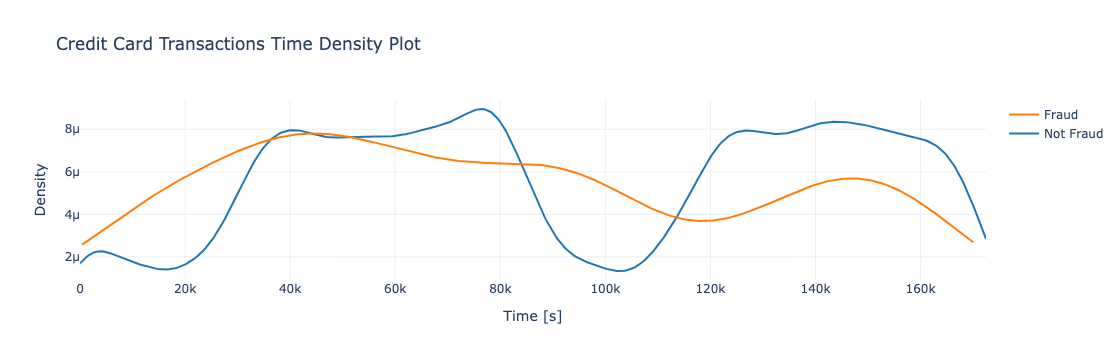

In [58]:
# Prepare data for the distribution plot
hist_data = [class_0, class_1]
group_labels = ['Not Fraud', 'Fraud']

# Create the distribution plot
fig = ff.create_distplot(hist_data, group_labels, show_hist=False, show_rug=False)

# Update the layout for better visuals
fig.update_layout(
    title='Credit Card Transactions Time Density Plot',
    xaxis_title='Time [s]',
    yaxis_title='Density',
    template='plotly_white'
)

# Display the plot
iplot(fig, filename='dist_only')

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



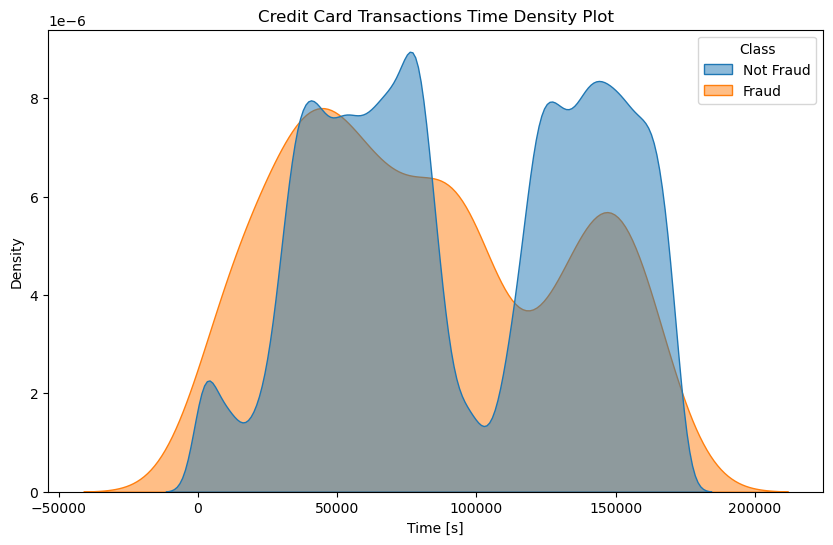

In [62]:
# Convert 'Class' to categorical labels
df_cleaned['Class'] = df_cleaned['Class'].map({0: 'Not Fraud', 1: 'Fraud'})

# Plot using Seaborn
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_cleaned, x='Time', hue='Class', fill=True, common_norm=False, alpha=0.5)
plt.title('Credit Card Transactions Time Density Plot')
plt.xlabel('Time [s]')
plt.ylabel('Density')
plt.show()


In [64]:
df_cleaned['Hour'] = df_cleaned['Time'].apply(lambda x: np.floor(x / 3600))

# Step 2: Group data by 'Hour' and 'Class', and calculate the required statistics
grouped_stats = df_cleaned.groupby(['Hour', 'Class'])['Amount'].agg(
    Min='min', Max='max', Transactions='count', Sum='sum',
    Mean='mean', Median='median', Var='var'
).reset_index()

# Step 3: Display the first few rows of the grouped DataFrame
grouped_stats.head()

,Hour,Class,Min,Max,Transactions,Sum,Mean,Median,Var
0,0.0,Fraud,0.0,529.00,2,529.00,264.500000,264.500,139920.500000
1,0.0,Not Fraud,0.0,7712.43,3961,256572.87,64.774772,12.990,45615.821201
2,1.0,Fraud,59.0,239.93,2,298.93,149.465000,149.465,16367.832450
3,1.0,Not Fraud,0.0,1769.69,2215,145806.76,65.826980,22.820,20053.615770
4,2.0,Fraud,1.0,1809.68,21,1829.78,87.132381,1.000,155776.441219


/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



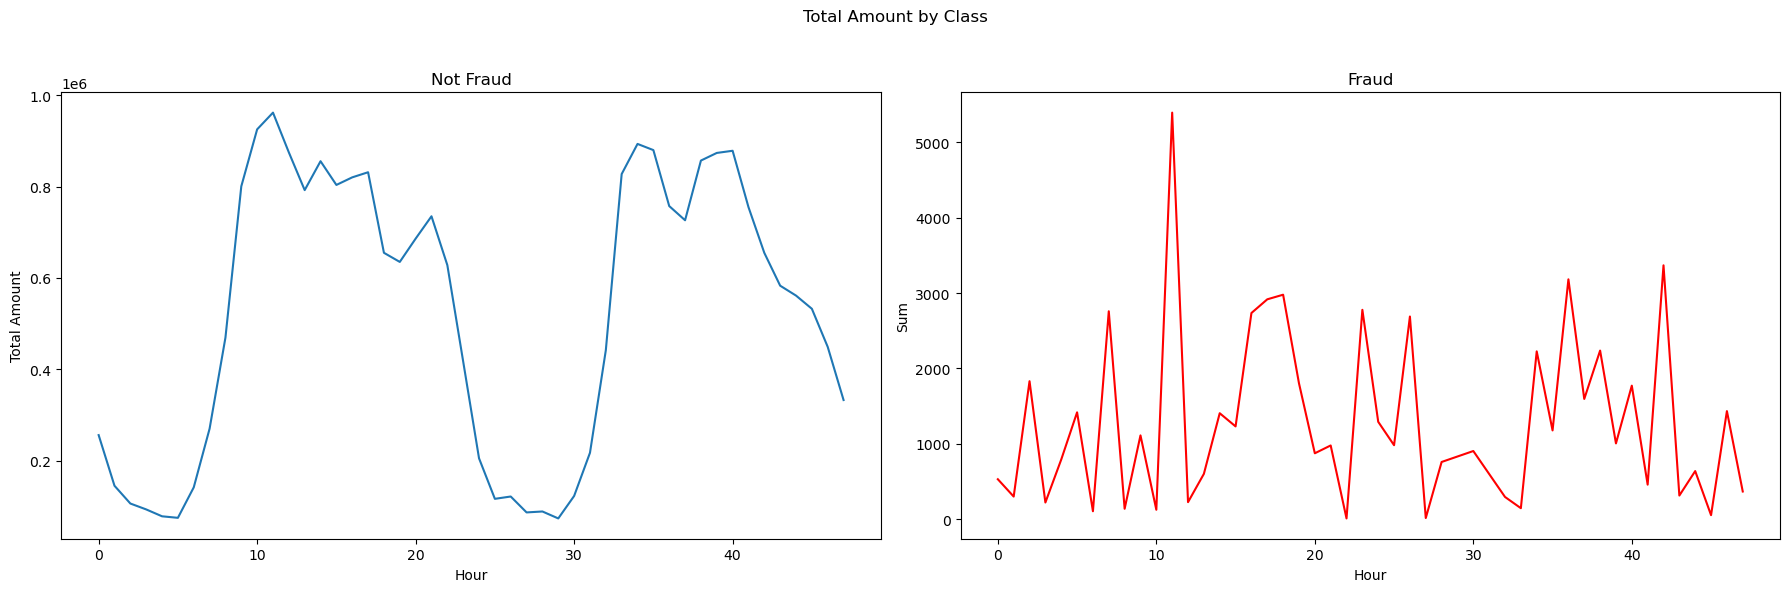

In [90]:

df = df.dropna(subset=['Time', 'Class', 'Amount'])  # Drop rows with null values in key columns
df['Hour'] = np.floor(df['Time'] / 3600)  # Calculate hour from time

# Group the data
df_grouped = df.groupby(['Hour', 'Class'])['Amount'].agg(
    Min='min', Max='max', Transactions='count', Sum='sum',
    Mean='mean', Median='median', Var='var'
).reset_index()

# Plotting
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18, 6))

# Check for data presence before plotting
if not df_grouped[df_grouped['Class'] == 0].empty:
    sns.lineplot(ax=ax1, x="Hour", y="Sum", data=df_grouped[df_grouped['Class'] == 0])
    ax1.set_title('Not Fraud')
    ax1.set_xlabel('Hour')
    ax1.set_ylabel('Total Amount')
else:
    ax1.set_title('Not Fraud')
    ax1.set_ylabel('Total Amount')
    ax1.text(0.5, 0.5, 'No Data Available', horizontalalignment='center', verticalalignment='center', transform=ax1.transAxes)

if not df_grouped[df_grouped['Class'] == 1].empty:
    sns.lineplot(ax=ax2, x="Hour", y="Sum", data=df_grouped[df_grouped['Class'] == 1], color="red")
    ax2.set_title('Fraud')
    ax2.set_xlabel('Hour')
else:
    ax2.set_title('Fraud')
    ax2.text(0.5, 0.5, 'No Data Available', horizontalalignment='center', verticalalignment='center', transform=ax2.transAxes)

plt.suptitle("Total Amount by Class")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


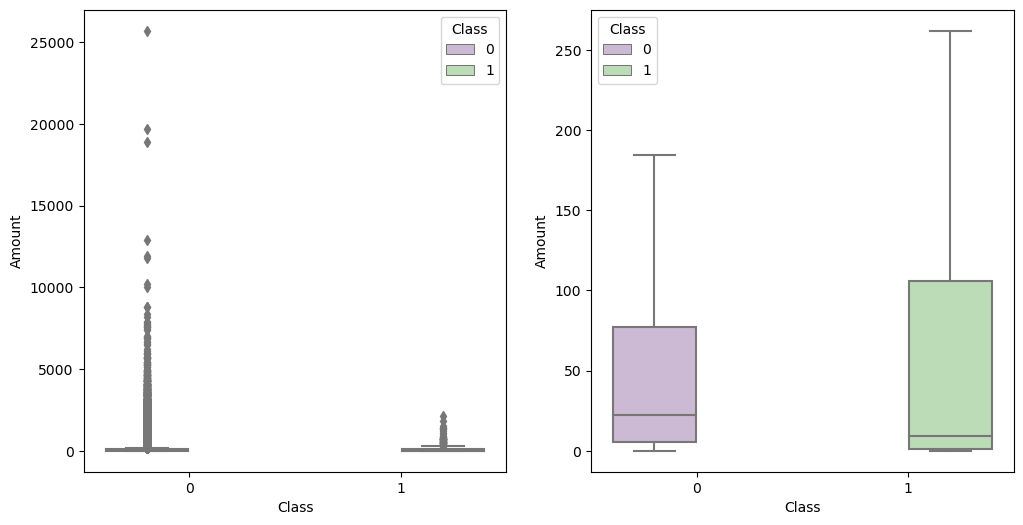

In [98]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,6))
s = sns.boxplot(ax = ax1, x="Class", y="Amount", hue="Class",data=df, palette="PRGn",showfliers=True)
s = sns.boxplot(ax = ax2, x="Class", y="Amount", hue="Class",data=df, palette="PRGn",showfliers=False)
plt.show();

In [100]:
tmp = df[['Amount','Class']].copy()
class_0 = tmp.loc[tmp['Class'] == 0]['Amount']
class_1 = tmp.loc[tmp['Class'] == 1]['Amount']
class_0.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [102]:
class_1.describe()


count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

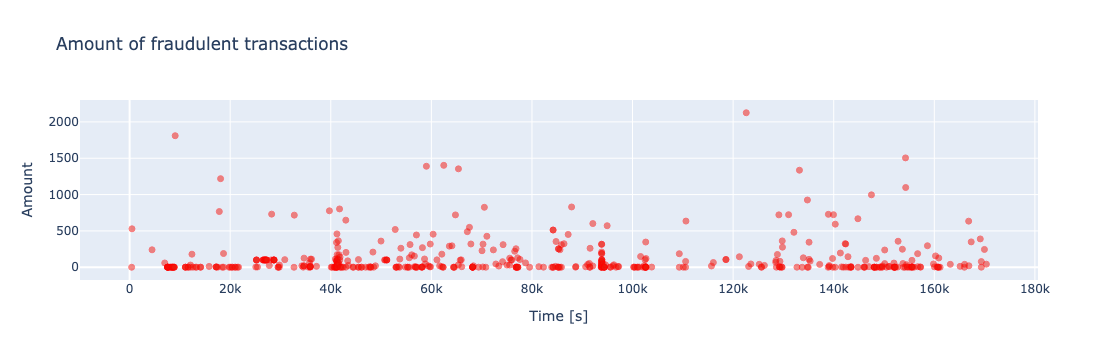

In [104]:
fraud = df.loc[df['Class'] == 1]

trace = go.Scatter(
    x = fraud['Time'],y = fraud['Amount'],
    name="Amount",
     marker=dict(
                color='rgb(238,23,11)',
                line=dict(
                    color='red',
                    width=1),
                opacity=0.5,
            ),
    text= fraud['Amount'],
    mode = "markers"
)
data = [trace]
layout = dict(title = 'Amount of fraudulent transactions',
          xaxis = dict(title = 'Time [s]', showticklabels=True), 
          yaxis = dict(title = 'Amount'),
          hovermode='closest'
         )
fig = dict(data=data, layout=layout)
iplot(fig, filename='fraud-amount')

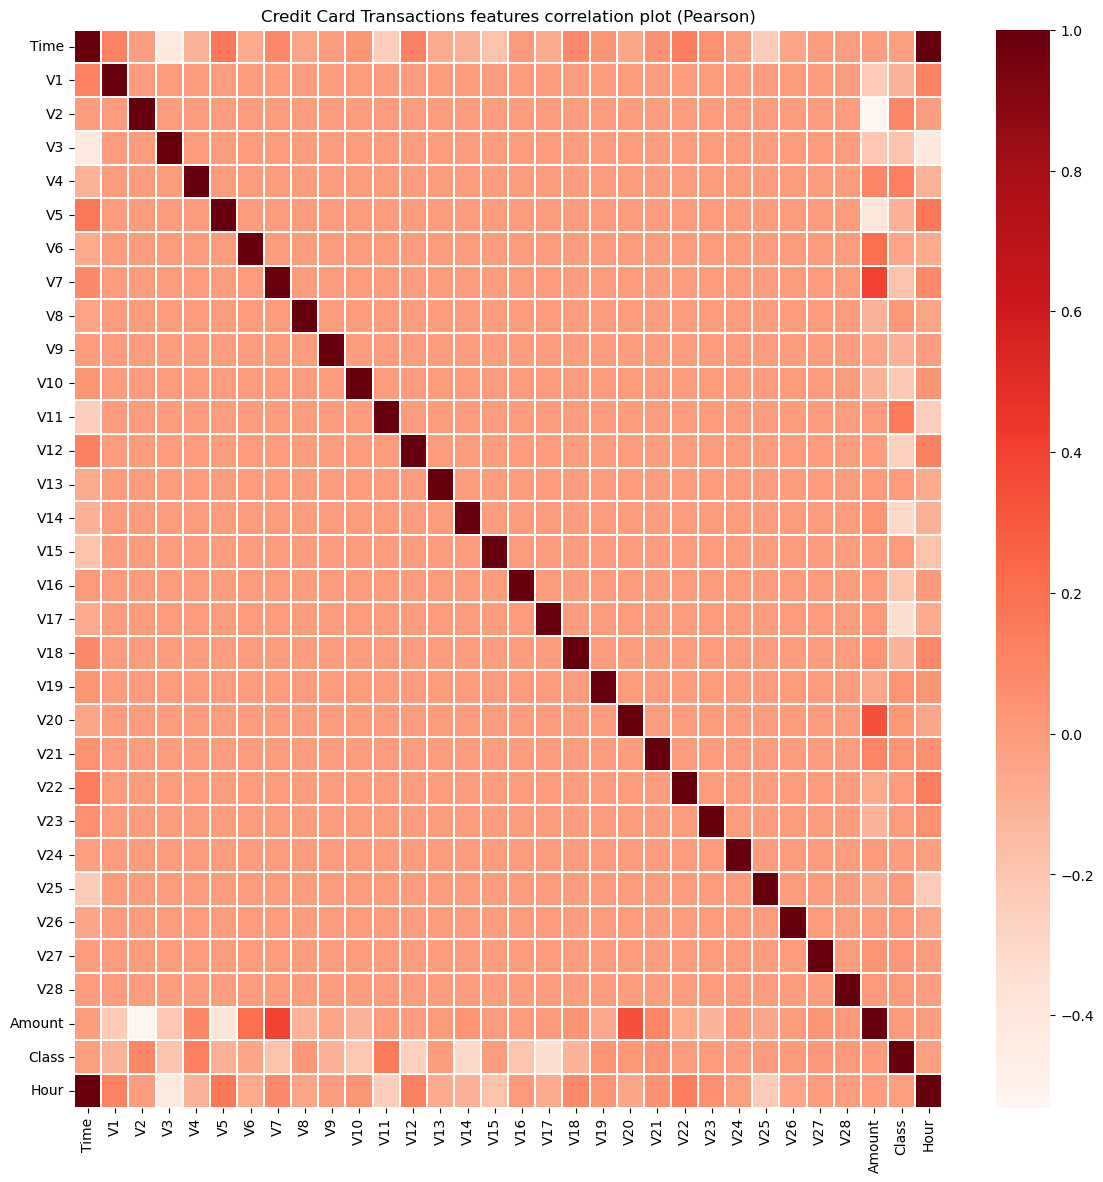

In [106]:
plt.figure(figsize = (14,14))
plt.title('Credit Card Transactions features correlation plot (Pearson)')
corr = df.corr()
sns.heatmap(corr,xticklabels=corr.columns,yticklabels=corr.columns,linewidths=.1,cmap="Reds")
plt.show()

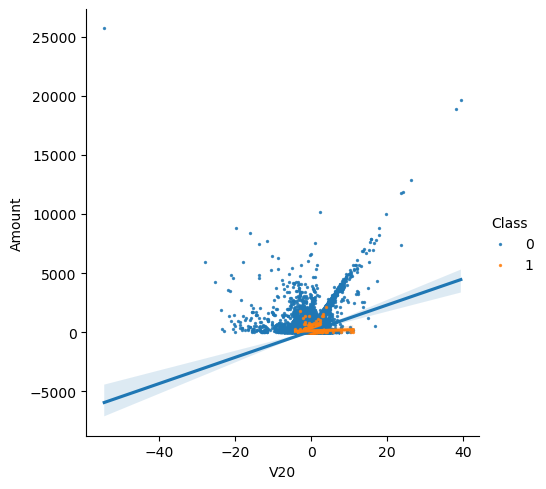

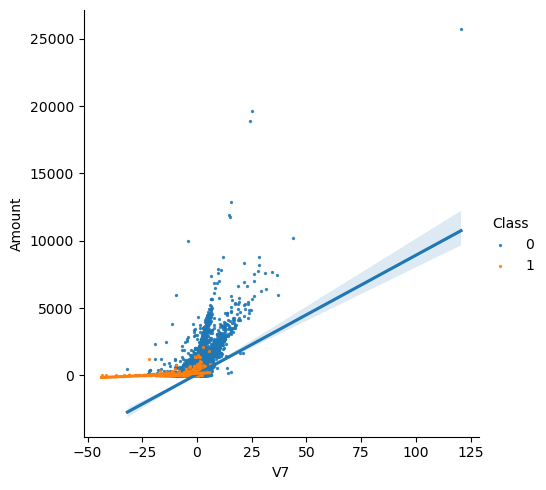

In [108]:
s = sns.lmplot(x='V20', y='Amount',data=df, hue='Class', fit_reg=True,scatter_kws={'s':2})
s = sns.lmplot(x='V7', y='Amount',data=df, hue='Class', fit_reg=True,scatter_kws={'s':2})
plt.show()

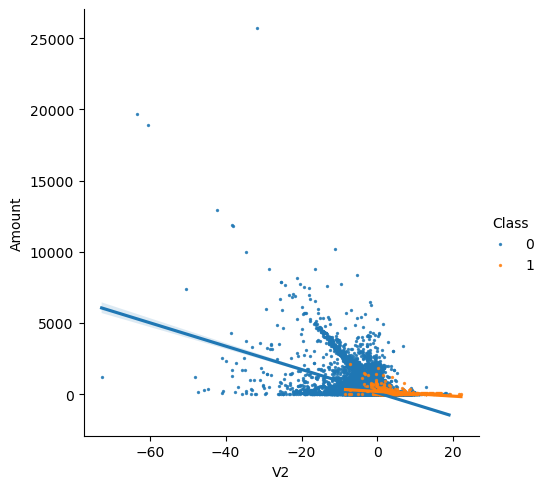

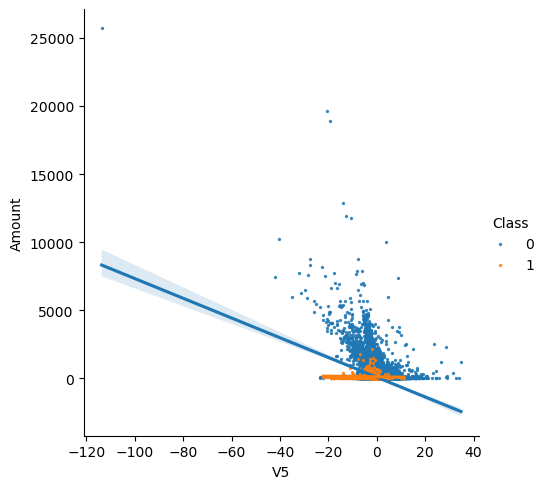

In [110]:
s = sns.lmplot(x='V2', y='Amount',data=df, hue='Class', fit_reg=True,scatter_kws={'s':2})
s = sns.lmplot(x='V5', y='Amount',data=df, hue='Class', fit_reg=True,scatter_kws={'s':2})
plt.show()

/var/folders/p7/r2bc5sns1p32y6vh9b8tp3pm0000gn/T/ipykernel_89471/2137072470.py:14: UserWarning:



The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.13.0.


/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/var/folders/p7/r2bc5sns1p32y6vh9b8tp3pm0000gn/T/ipykernel_89471/2137072470.py:15: UserWarning:



The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.13.0.


/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be remo

<Figure size 640x480 with 0 Axes>

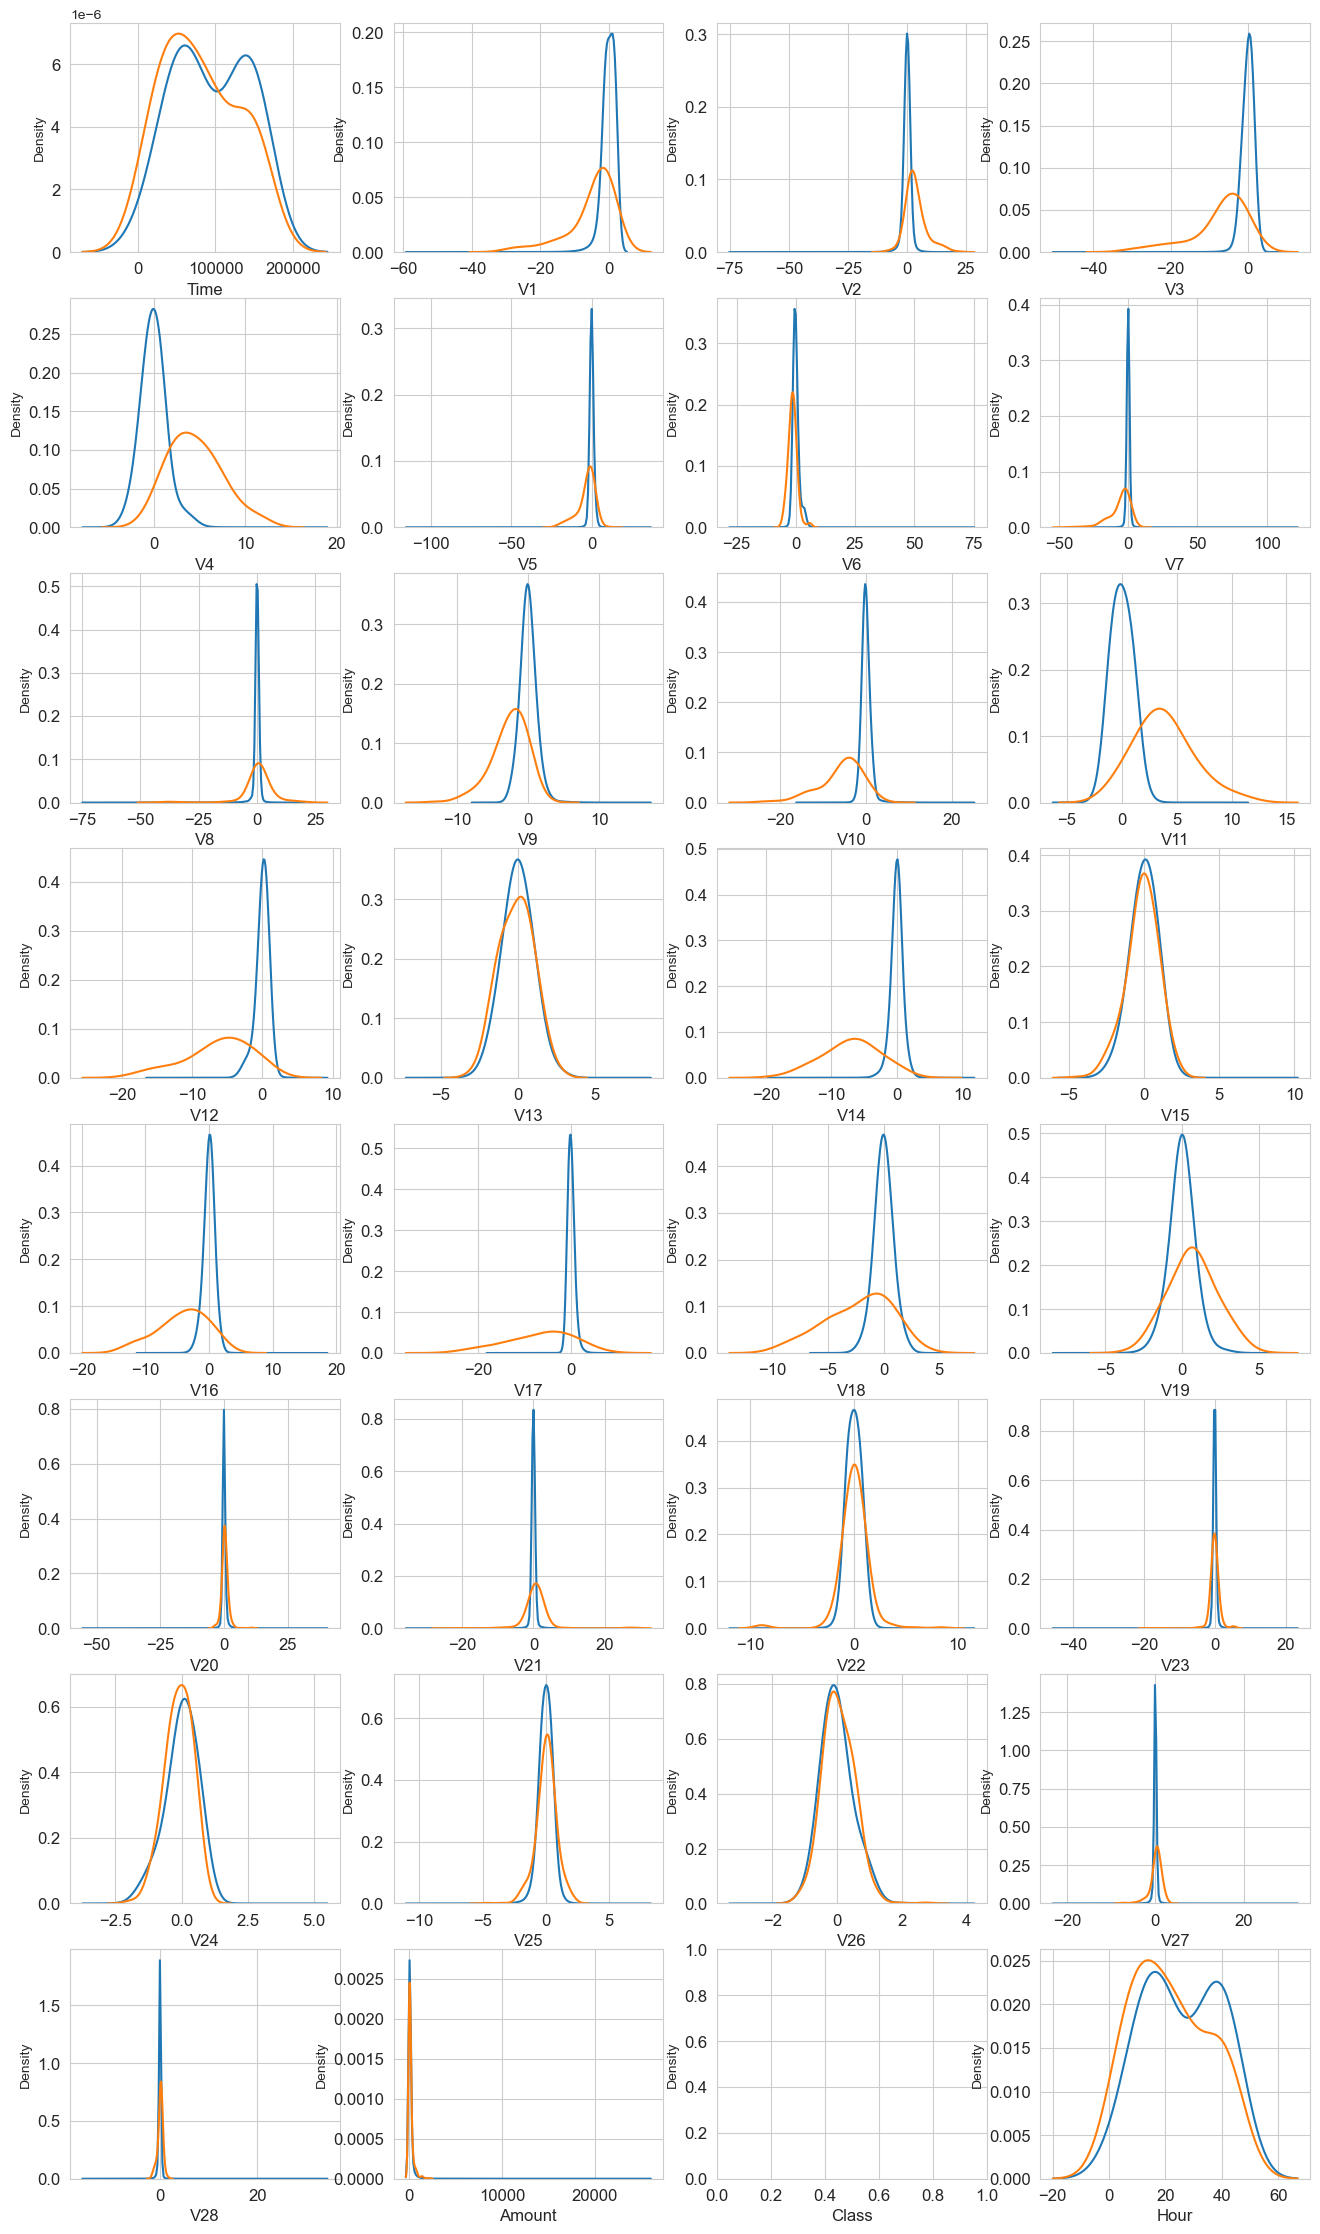

In [112]:
var = df.columns.values

i = 0
t0 = df.loc[df['Class'] == 0]
t1 = df.loc[df['Class'] == 1]

sns.set_style('whitegrid')
plt.figure()
fig, ax = plt.subplots(8,4,figsize=(16,28))

for feature in var:
    i += 1
    plt.subplot(8,4,i)
    sns.kdeplot(t0[feature], bw=0.5,label="Class = 0")
    sns.kdeplot(t1[feature], bw=0.5,label="Class = 1")
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()
    plt.tick_params(axis='both', which='major', labelsize=12)
plt.show();

In [114]:
target = 'Class'
predictors = ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',\
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19',\
       'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28',\
       'Amount']

In [136]:
VALID_SIZE = 0.20 # simple validation using train_test_split
TEST_SIZE = 0.20
NUMBER_KFOLDS = 5 #number of KFolds for cross-validation



RANDOM_STATE = 2018

MAX_ROUNDS = 1000 #lgb iterations
EARLY_STOP = 50 #lgb early stop 
OPT_ROUNDS = 1000  #To be adjusted based on best validation rounds
VERBOSE_EVAL = 50 #Print out metric result
NO_JOBS = 4 
RFC_METRIC = 'gini'  #metric used for RandomForrestClassifier
NUM_ESTIMATORS = 100
NUMBER_KFOLDS = 5 #number of KFolds for cross-validation



RANDOM_STATE = 2018

MAX_ROUNDS = 1000 #lgb iterations
EARLY_STOP = 50 #lgb early stop 
OPT_ROUNDS = 1000  #To be adjusted based on best validation rounds
VERBOSE_EVAL = 50 #Print out metric result

IS_LOCAL = False

In [138]:
train_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True )
train_df, valid_df = train_test_split(train_df, test_size=VALID_SIZE, random_state=RANDOM_STATE, shuffle=True )

In [140]:
clf = RandomForestClassifier(n_jobs=NO_JOBS, 
                             random_state=RANDOM_STATE,
                             criterion=RFC_METRIC,
                             n_estimators=NUM_ESTIMATORS,
                             verbose=False)

In [142]:
clf.fit(train_df[predictors], train_df[target].values)

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


RandomForestClassifier(n_jobs=4, random_state=2018, verbose=False)

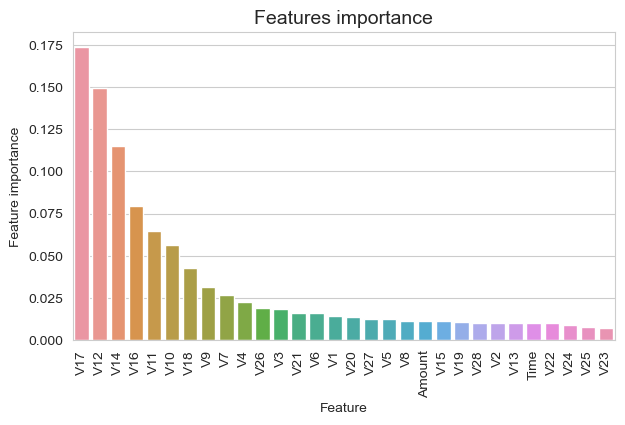

In [144]:
tmp = pd.DataFrame({'Feature': predictors, 'Feature importance': clf.feature_importances_})
tmp = tmp.sort_values(by='Feature importance',ascending=False)
plt.figure(figsize = (7,4))
plt.title('Features importance',fontsize=14)
s = sns.barplot(x='Feature',y='Feature importance',data=tmp)
s.set_xticklabels(s.get_xticklabels(),rotation=90)
plt.show()   

In [148]:
preds = clf.predict(valid_df[predictors])


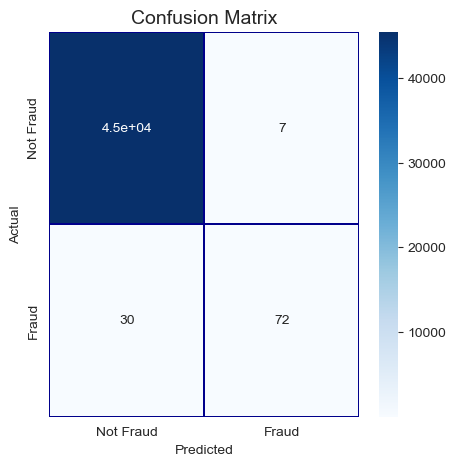

In [150]:
cm = pd.crosstab(valid_df[target].values, preds, rownames=['Actual'], colnames=['Predicted'])
fig, (ax1) = plt.subplots(ncols=1, figsize=(5,5))
sns.heatmap(cm, 
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'],
            annot=True,ax=ax1,
            linewidths=.2,linecolor="Darkblue", cmap="Blues")
plt.title('Confusion Matrix', fontsize=14)
plt.show()

In [152]:
roc_auc_score(valid_df[target].values, preds)


0.8528641975628091

In [154]:
dtrain = xgb.DMatrix(train_df[predictors], train_df[target].values)
dvalid = xgb.DMatrix(valid_df[predictors], valid_df[target].values)
dtest = xgb.DMatrix(test_df[predictors], test_df[target].values)

#What to monitor (in this case, **train** and **valid**)
watchlist = [(dtrain, 'train'), (dvalid, 'valid')]

# Set xgboost parameters
params = {}
params['objective'] = 'binary:logistic'
params['eta'] = 0.039
params['silent'] = True
params['max_depth'] = 2
params['subsample'] = 0.8
params['colsample_bytree'] = 0.9
params['eval_metric'] = 'auc'
params['random_state'] = RANDOM_STATE

In [156]:
model = xgb.train(params, 
                dtrain, 
                MAX_ROUNDS, 
                watchlist, 
                early_stopping_rounds=EARLY_STOP, 
                maximize=True, 
                verbose_eval=VERBOSE_EVAL)

[0]	train-auc:0.94070	valid-auc:0.88630


/opt/homebrew/anaconda3/lib/python3.11/site-packages/xgboost/core.py:727: FutureWarning:

Pass `evals` as keyword args.

/opt/homebrew/anaconda3/lib/python3.11/site-packages/xgboost/core.py:160: UserWarning:

[20:58:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "silent" } are not used.




[50]	train-auc:0.94045	valid-auc:0.89040
[100]	train-auc:0.97428	valid-auc:0.96302
[150]	train-auc:0.98695	valid-auc:0.98056
[200]	train-auc:0.99276	valid-auc:0.98504
[250]	train-auc:0.99514	valid-auc:0.98432
[267]	train-auc:0.99569	valid-auc:0.98373


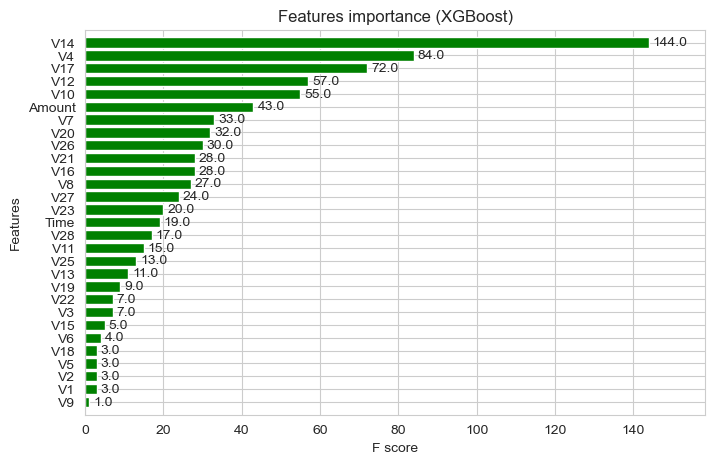

In [158]:
fig, (ax) = plt.subplots(ncols=1, figsize=(8,5))
xgb.plot_importance(model, height=0.8, title="Features importance (XGBoost)", ax=ax, color="green") 
plt.show()

In [160]:
preds = model.predict(dtest)


In [162]:
roc_auc_score(test_df[target].values, preds)


0.9806594034680455